### Generate Figure 4 from the paper.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import time
from numba import njit
codedir = "../src/"

sys.path.append(os.path.abspath(codedir))

import smplotlib 
from Vlasov_integrators_thick_disk import *

from dimensionless_to_physical_units import *


from axisymmetric_stability import *

In [2]:
kxval = 0.0
kappa_val=1
hgKO=0.87 
hsKO = 0.4

In [3]:
from paper_case_points import (
    POINTS_THIN_DISKS as points_thin_disks,
    POINTS_THICK_DISKS as points_thick_disks,
    THIN_DISK_MARKERS as thin_disk_marker,
    THICK_DISK_MARKERS as thick_disk_marker,
    scatter_marker_size,
)

In [4]:
def Kfunc_kernel(t,ti, kyval, Sigma_s_val, sigma_x_val, Omega0_val, hs):
    return njit_K_kernel_func(t, ti, kxval, kyval, Sigma_s_val, kappa_val, Omega0_val, sigma_x_val, hs*sigma_x_val/kappa_val, G=1)


def Kfunc_kernel_max(tf,ti, kyval, Sigma_s_val, sigma_x_val, Omega0_val, hs, nvals = 500):
    tgrid= np.linspace(ti,tf, nvals)

    Kvals = np.abs(np.array([Kfunc_kernel(t,ti, kyval, Sigma_s_val, sigma_x_val, Omega0_val, hs) for t in tgrid]))

    return float(np.max(Kvals))


def get_self_gravity_response_max_gas_plus_stars(tf,ti, kyval, Rvals, Qgas, Qstars, hg, hs,  nvals = 500):
    _, _, Sigma_g_val, Sigma_s_val, sigma_x_val, cssq_val , Omega0_val, _ = \
    get_physical_densities_and_speed_of_sounds_from_rafikov_dimensionless_variables_for_paper(0.0, 0.0,Qgas, Qstars, Rvals, kappa=kappa_val)
    sim = Gas_plus_stars_integrator(
        kx=kxval, kyc=kyval, Sigma_g= Sigma_g_val, 
        Sigma_s=Sigma_s_val,
        kappa = kappa_val, 
        Omega0 = Omega0_val, 
        sigma_x = sigma_x_val,
        cssq = cssq_val,
        Hg = hg*np.sqrt(cssq_val)/kappa_val,
        Hs = hs*sigma_x_val/kappa_val,
        G=1)

    t_grid = np.linspace(ti, tf, nvals)
    results = sim.solve(t_grid, fext_params={'delta': 0.0, 'amplitude' : 0}, impulse_params = {"t_0": ti, "Sigma_impluse" : 1})

    surface_densities_stellar = np.abs(sim.get_stellar_surface_density(results, t_grid))

    return np.max(surface_densities_stellar)

def get_plotting_arr(RvalQgQs,hg,hs, kcritvals, tivals):
    plotting_arr = []

    for val in RvalQgQs:
        start = time.perf_counter()
        Rvals, Qgas, Qstars = val
        _, _, Sigma_g_val, Sigma_s_val, sigma_x_val, cssq_val , Omega0_val, _ = \
                get_physical_densities_and_speed_of_sounds_from_rafikov_dimensionless_variables_for_paper(0.0, 0.0,Qgas, Qstars, Rvals, kappa=kappa_val)
        print(Sigma_g_val)
        maxvals = []
        print("-------")
        for j in range(len(kcritvals)):
            maximum = 0.0
            maxnum = 0.0
            maxdenum = 0.0
            for ti in tivals:
                
                num = get_self_gravity_response_max_gas_plus_stars(20,ti, kcritvals[j], Rvals, Qgas, Qstars, hg, hs, 100)
                
                denum = Kfunc_kernel_max(20, ti, kcritvals[j], Sigma_s_val, sigma_x_val, Omega0_val, hs, 100)
                
                # maximum = max(maximum,  num/denum)
    
                maxdenum = max(maxdenum,  denum)
                maxnum = max(maxnum,  num)
    
                # if(denum<1e-10):
                #     print("ti = ",ti,"; ky = ",kcritvals[j], "; max = ", maximum, "; num = ",num, "; denum = ", denum)
    
            maximum = maxnum/maxdenum
            maxvals.append(maximum)
    
        plotting_arr.append([val, maxvals])
    
        end = time.perf_counter()
    
        print(f"Elapsed time: {end - start:.6f} seconds")

    return plotting_arr

In [ ]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt


# Relative sizes chosen so that different marker shapes
# have approximately the same visual prominence.
MARKER_SIZE_SCALE = {
    "D": 0.85,
    "o": 1.00,
    "*": 1.15,
}


def get_marker_size(marker, base_size=8.0):
    """
    Return a visually normalized marker size for plt.plot/Line2D.

    Parameters
    ----------
    marker : str
        Matplotlib marker symbol.
    base_size : float
        Reference marker size for a circular marker.
    """
    return base_size * MARKER_SIZE_SCALE.get(marker, 1.0)


def get_default_max_amp_rows():
    rows = [
        {
            "Qg": points_thin_disks[2][1],
            "Qs": points_thin_disks[2][0],
            "hg": 0.0,
            "hs": 0.0,
            "marker": thin_disk_marker[2],
            "markersize": get_marker_size(thin_disk_marker[2]),
            "marker_color": "red",
            "yscale": "log",
        },
        {
            "Qg": points_thin_disks[0][1],
            "Qs": points_thin_disks[0][0],
            "hg": 0.0,
            "hs": 0.0,
            "marker": thin_disk_marker[0],
            "markersize": get_marker_size(thin_disk_marker[0]),
            "marker_color": "red",
            "yscale": "log",
        },
        {
            "Qg": points_thin_disks[1][1],
            "Qs": points_thin_disks[1][0],
            "hg": 0.0,
            "hs": 0.0,
            "marker": thin_disk_marker[1],
            "markersize": get_marker_size(thin_disk_marker[1]),
            "marker_color": "red",
            "yscale": "log",
        },
        {
            "Qg": points_thick_disks[0][1],
            "Qs": points_thick_disks[0][0],
            "hg": 0.87,
            "hs": 0.4,
            "marker": thick_disk_marker[0],
            "markersize": get_marker_size(thick_disk_marker[0]),
            "marker_color": "blue",
            "yscale": "log",
        },
    ]

    return rows


def generate_max_swing_amplification_data(
    kcritvals,
    tivals,
    rows=None,
    R_values=(1.0, 0.7, 0.4),
):
    """
    Expensive data-generation step.

    Returns a dictionary containing the computed maximum amplification curves.
    You can reuse the returned data for different plotting styles.
    """

    if rows is None:
        rows = get_default_max_amp_rows()

    kcritvals = np.asarray(kcritvals)
    tivals = np.asarray(tivals)

    lambda_over_lcrit = 1.0 / kcritvals
    order = np.argsort(lambda_over_lcrit)

    data = {
        "kcritvals": kcritvals,
        "tivals": tivals,
        "lambda_over_lcrit": lambda_over_lcrit[order],
        "R_values": list(R_values),
        "rows": [],
    }

    for row in rows:
        Qg = row["Qg"]
        Qs = row["Qs"]
        hg = row["hg"]
        hs = row["hs"]

        RvalQgQs = [
            [Rval, Qg, Qs]
            for Rval in R_values
        ]

        plotting_arr = get_plotting_arr(
            RvalQgQs,
            hg=hg,
            hs=hs,
            kcritvals=kcritvals,
            tivals=tivals,
        )

        row_data = dict(row)
        row_data["curves"] = []

        for item in plotting_arr:
            params, maxvals = item
            Rval, Qg_check, Qs_check = params

            maxvals = np.asarray(maxvals)

            curve_data = {
                "R": Rval,
                "Qg": Qg_check,
                "Qs": Qs_check,
                "maxvals": maxvals[order],
            }

            row_data["curves"].append(curve_data)

        data["rows"].append(row_data)

    return data

In [6]:
def plot_max_swing_amplification_from_data(
    data,
    R_colors=("red", "green", "blue"),
    figsize=(5.0, 8.8),
    xlim=(0.0, 6.0),
    save=False,
    filename="max_swing_amplification.pdf",
):
    """
    Plot precomputed maximum swing amplification data.

    Adds panel labels and titles showing Qs, Qg, hs, hg.
    """

    lambda_over_lcrit = data["lambda_over_lcrit"]
    rows = data["rows"]
    R_values = data["R_values"]

    R_color_map = {
        Rval: color
        for Rval, color in zip(R_values, R_colors)
    }

    fig, axes = plt.subplots(
        len(rows),
        1,
        figsize=figsize,
        sharex=True,
    )

    if len(rows) == 1:
        axes = np.array([axes])

    panel_labels = list("abcdefghijklmnopqrstuvwxyz")

    def get_row_params(row):
        """
        Try to extract Qs, Qg, hs, hg robustly.

        Expected preferred format:
            row["point"] = (Qs, Qg)
            row["hs"]
            row["hg"]
        """

        if "point" in row:
            Qs, Qg = row["point"]
        else:
            Qs = row.get("Qs", row.get("Qstars", np.nan))
            Qg = row.get("Qg", row.get("Qgas", np.nan))

        hs = row.get("hs", row.get("hstars", 0.0))
        hg = row.get("hg", row.get("hgas", 0.0))

        return Qs, Qg, hs, hg

    for i, row in enumerate(rows):
        ax = axes[i]

        Qs, Qg, hs, hg = get_row_params(row)

        for curve in row["curves"]:
            Rval = curve["R"]
            maxvals = curve["maxvals"]

            ax.plot(
                lambda_over_lcrit,
                maxvals,
                color=R_color_map[Rval],
                lw=1.0,
                label=rf"$r = {Rval}$",
            )

        ax.set_yscale(row.get("yscale", "log"))
        ax.set_ylabel("max. amplification", fontsize = 12,)

        # Panel label
        ax.text(
            0.04,
            0.92,
            rf"({panel_labels[i]})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize = 12,
        )

        # Marker only
        ax.plot(
            0.94,
            0.9,
            marker=row["marker"],
            color=row["marker_color"],
            markerfacecolor=row["marker_color"],
            markeredgecolor=row["marker_color"],
            markersize=row["markersize"],
            linestyle="None",
            transform=ax.transAxes,
            clip_on=False,
        )

        # Subplot title
        ax.set_title(
            rf"$Q_s={Qs:.3g},\ Q_g={Qg:.3g},\ h_s={hs:.3g},\ h_g={hg:.3g}$",
            pad=4,
            fontsize = 12,
        )

        ax.tick_params(
            which="major",
            direction="in",
            top=True,
            right=True,
            length=6,
        )

        ax.tick_params(
            which="minor",
            direction="in",
            top=True,
            right=True,
            length=3,
        )

        if i == 0:
            ax.legend(
                loc="center right",
                frameon=False,
                fontsize = 12,
            )

    axes[-1].set_xlabel(r"$\lambda/\lambda_{\rm crit}$")

    if xlim is not None:
        axes[-1].set_xlim(*xlim)

    fig.subplots_adjust(
        left=0.18,
        right=0.96,
        bottom=0.08,
        top=0.96,
        hspace=0.24,
    )

    if save:
        fig.savefig(filename, bbox_inches="tight")

    return fig, axes

In [7]:
kcritvals = np.sort(1.0/np.linspace(0.1, 10, 150))
tivals = np.linspace(-20, 18, 150)

In [8]:
# Expensive step: run once
max_amp_data = generate_max_swing_amplification_data(
    kcritvals=kcritvals,
    tivals=tivals,
    R_values=(1.0, 0.7, 0.4),
)

0.06366197723675814
-------
Elapsed time: 23.739616 seconds
0.044563384065730696
-------
Elapsed time: 22.176748 seconds
0.025464790894703257
-------
Elapsed time: 21.869985 seconds
0.22281692032865347
-------
Elapsed time: 22.750413 seconds
0.15597184423005742
-------
Elapsed time: 22.379350 seconds
0.08912676813146139
-------
Elapsed time: 22.611946 seconds
0.144686311901723
-------
Elapsed time: 22.390716 seconds
0.1012804183312061
-------
Elapsed time: 22.526658 seconds
0.05787452476068921
-------
Elapsed time: 22.362931 seconds
0.23578510087688198
-------
Elapsed time: 22.300071 seconds
0.1650495706138174
-------
Elapsed time: 21.824537 seconds
0.0943140403507528
-------
Elapsed time: 22.037627 seconds


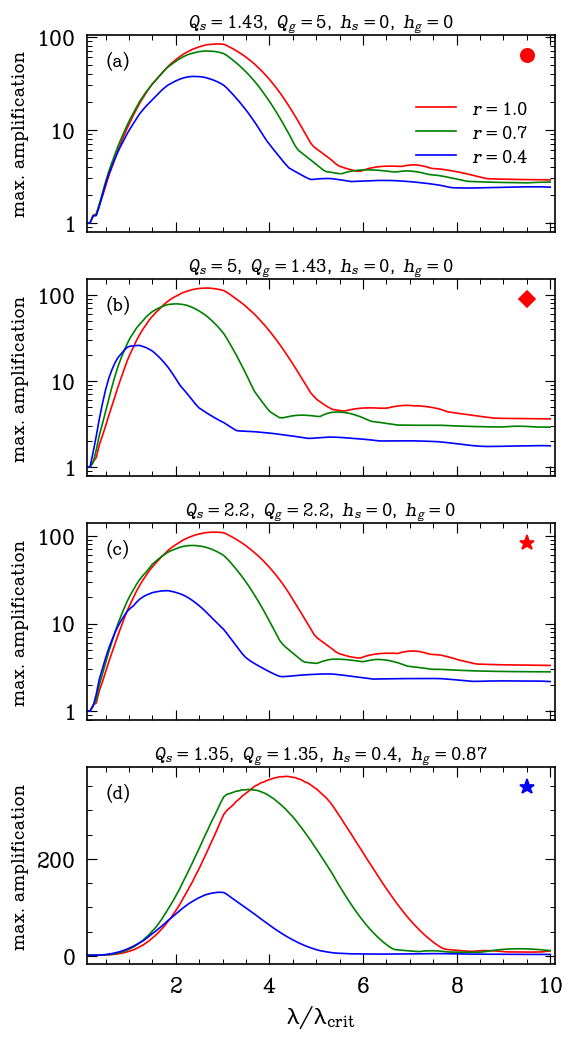

In [10]:
# Cheap plotting step: rerun as many times as you want
fig, axes = plot_max_swing_amplification_from_data(
    max_amp_data,
    R_colors=("red", "green", "blue"),
    figsize=(5.0, 8.8),
    save=True,
    xlim=(0.1,10.1),
    filename="./Figures/max_swing_amplification.pdf"
)

plt.show()